In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MIoU_ZS_PATH   = "../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv"
MIoU_LORA_PATH = "../inference/clipseg_cloudsen12plus_lora_lr5e-5_r32_a64_ep8/miou_clipseg_cloudsen12plus_zs_eval.csv"
CM_ZS_PATH     = "../inference/clipseg_cloudsen12plus_zs/cm_clipseg_cloudsen12plus_zs_eval.csv"
CM_LORA_PATH   = "../inference/clipseg_cloudsen12plus_lora_lr5e-5_r32_a64_ep8/cm_clipseg_cloudsen12plus_zs_eval.csv"

CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]
N_CLASSES = len(CLASS_NAMES)

In [4]:
miou_zs   = pd.read_csv(MIoU_ZS_PATH)
miou_lora = pd.read_csv(MIoU_LORA_PATH)
cm_zs     = pd.read_csv(CM_ZS_PATH)
cm_lora   = pd.read_csv(CM_LORA_PATH)

ids_zs = set(miou_zs["id"]) - {"__aggregate__"}
ids_l  = set(miou_lora["id"]) - {"__aggregate__"}
common_ids = sorted(list(ids_zs & ids_l))

print("ZS images:", len(ids_zs))
print("LoRA images:", len(ids_l))
print("Common images:", len(common_ids))

miou_zs_p   = miou_zs[miou_zs["id"].isin(common_ids)].copy()
miou_lora_p = miou_lora[miou_lora["id"].isin(common_ids)].copy()
cm_zs_p     = cm_zs[cm_zs["id"].isin(common_ids)].copy()
cm_lora_p   = cm_lora[cm_lora["id"].isin(common_ids)].copy()


ZS images: 975
LoRA images: 975
Common images: 975


In [5]:
def confusion_from_row(row, n=N_CLASSES, prefix="cm_"):
    m = np.zeros((n, n), dtype=np.int64)
    for i in range(n):
        for j in range(n):
            col = f"{prefix}t{i}_p{j}"
            m[i, j] = int(row[col])
    return m

In [6]:
def aggregate_confusion(df, n=N_CLASSES):
    mats = []
    for _, r in df.iterrows():
        mats.append(confusion_from_row(r, n=n))
    return np.sum(mats, axis=0)

CM_ZS_GLOBAL   = aggregate_confusion(cm_zs_p)
CM_LORA_GLOBAL = aggregate_confusion(cm_lora_p)

CM_ZS_GLOBAL, CM_LORA_GLOBAL

(array([[80135845,  7794025, 34259639, 14078306],
        [ 5013861, 23687361, 36511317,  7863275],
        [ 5771701,  2278202,  9081365,  4853800],
        [ 6896402,  2272701,  8328250,  6764350]]),
 array([[124728641,   6912737,   1851417,   2775020],
        [  7700043,  61402266,   1419450,   2554055],
        [ 12714472,   4835625,   3336341,   1098630],
        [  8780387,   5320721,    766388,   9394207]]))

In [7]:
def metrics_from_confusion(cm, class_names=CLASS_NAMES):
    cm = cm.astype(np.int64)
    total = cm.sum()

    tp = np.diag(cm)
    row_sum = cm.sum(axis=1)
    col_sum = cm.sum(axis=0)

    fn = row_sum - tp
    fp = col_sum - tp

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) != 0)
    recall    = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fn) != 0)
    f1        = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp, dtype=float), where=(precision + recall) != 0)

    iou  = np.divide(tp, tp + fp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fp + fn) != 0)
    dice = np.divide(2 * tp, 2 * tp + fp + fn, out=np.zeros_like(tp, dtype=float), where=(2 * tp + fp + fn) != 0)

    pixel_acc = float(tp.sum() / total) if total else 0.0
    miou_macro = float(np.mean(iou))
    miou_freq = float(np.sum(iou * row_sum) / np.sum(row_sum)) if np.sum(row_sum) else 0.0
    bal_acc = float(np.mean(recall))

    per_class = pd.DataFrame({
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "dice": dice,
        "support_pixels": row_sum
    }, index=class_names)

    summary = pd.Series({
        "pixel_acc": pixel_acc,
        "mIoU_macro": miou_macro,
        "mIoU_freq_weighted": miou_freq,
        "balanced_acc": bal_acc,
        "total_pixels": int(total)
    })

    return summary, per_class


In [8]:
zs_summary, zs_pc = metrics_from_confusion(CM_ZS_GLOBAL)
l_summary,  l_pc  = metrics_from_confusion(CM_LORA_GLOBAL)

summary_df = pd.DataFrame([zs_summary, l_summary], index=["zero_shot", "lora"])
summary_df

,pixel_acc,mIoU_macro,mIoU_freq_weighted,balanced_acc,total_pixels
zero_shot,0.468206,0.255040,0.377109,0.401025,255590400.0
lora,0.778047,0.467321,0.636730,0.573633,255590400.0


In [9]:
per_class_df = zs_pc.add_prefix("zs_").join(l_pc.add_prefix("lora_"))
per_class_df["delta_iou"] = per_class_df["lora_iou"] - per_class_df["zs_iou"]
per_class_df["delta_f1"]  = per_class_df["lora_f1"]  - per_class_df["zs_f1"]

per_class_df.sort_values("delta_iou", ascending=False)

,zs_precision,zs_recall,zs_f1,zs_iou,zs_dice,zs_support_pixels,lora_precision,lora_recall,lora_f1,lora_iou,lora_dice,lora_support_pixels,delta_iou,delta_f1
thick_cloud,0.657393,0.324148,0.434200,0.277302,0.434200,73075814,0.782480,0.840254,0.810339,0.681151,0.810339,73075814,0.403849,0.376139
clear,0.819236,0.588076,0.684671,0.520532,0.684671,136267815,0.810329,0.915320,0.859630,0.753817,0.859630,136267815,0.233285,0.174959
cloud_shadow,0.201562,0.278808,0.233974,0.132486,0.233974,24261703,0.593747,0.387203,0.468731,0.306106,0.468731,24261703,0.173620,0.234757
thin_cloud,0.102986,0.413070,0.164867,0.089840,0.164867,21985068,0.452471,0.151755,0.227282,0.128211,0.227282,21985068,0.038371,0.062414


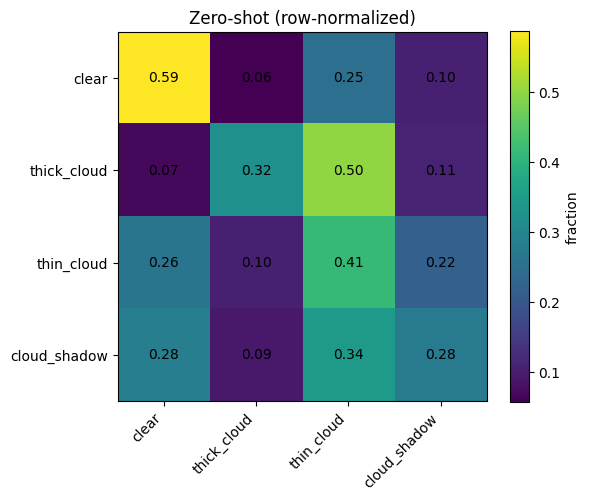

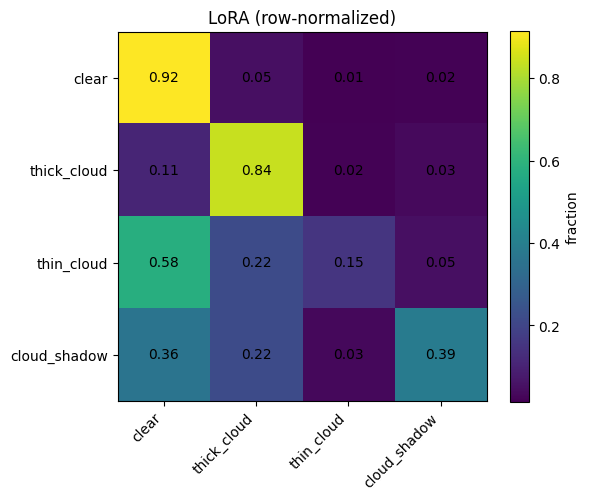

In [10]:
def plot_confusion(cm, title, normalize="true"):
    cm = cm.astype(float)

    if normalize == "true":
        denom = cm.sum(axis=1, keepdims=True)
    elif normalize == "pred":
        denom = cm.sum(axis=0, keepdims=True)
    else:
        denom = 1.0

    cmn = np.divide(cm, denom, out=np.zeros_like(cm), where=denom != 0)

    plt.figure(figsize=(6, 5))
    plt.imshow(cmn)
    plt.title(title)
    plt.xticks(range(N_CLASSES), CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(range(N_CLASSES), CLASS_NAMES)
    plt.colorbar(label="fraction")

    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            plt.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion(CM_ZS_GLOBAL,   "Zero-shot (row-normalized)", normalize="true")
plot_confusion(CM_LORA_GLOBAL, "LoRA (row-normalized)", normalize="true")


In [11]:
miou_zs_p = miou_zs_p.set_index("id").loc[common_ids].reset_index()
miou_lora_p = miou_lora_p.set_index("id").loc[common_ids].reset_index()

mzs = pd.to_numeric(miou_zs_p["miou"], errors="coerce")
ml  = pd.to_numeric(miou_lora_p["miou"], errors="coerce")
d   = ml - mzs

print("Mean mIoU (ZS):", float(mzs.mean()))
print("Mean mIoU (LoRA):", float(ml.mean()))
print("Mean ΔmIoU:", float(d.mean()))
print("Median ΔmIoU:", float(d.median()))
print("Images improved (%):", float((d > 0).mean() * 100))

Mean mIoU (ZS): 0.2120945548726987
Mean mIoU (LoRA): 0.47126484969972304
Mean ΔmIoU: 0.25917029482702436
Median ΔmIoU: 0.2171293055619878
Images improved (%): 91.6923076923077


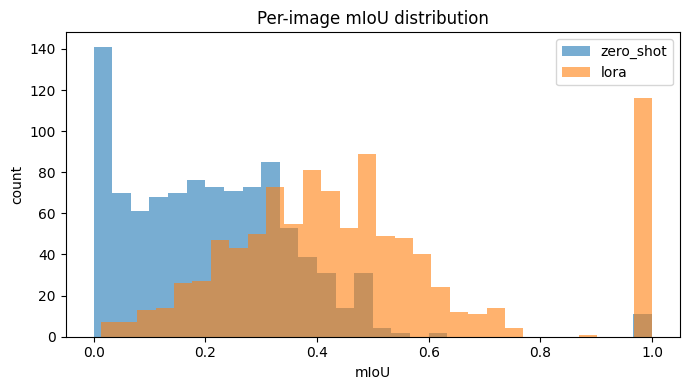

In [12]:
plt.figure(figsize=(7, 4))
plt.hist(mzs.dropna(), bins=30, alpha=0.6, label="zero_shot")
plt.hist(ml.dropna(),  bins=30, alpha=0.6, label="lora")
plt.title("Per-image mIoU distribution")
plt.xlabel("mIoU")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

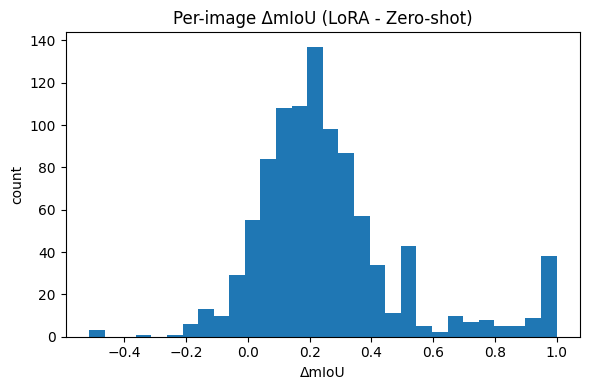

In [13]:
plt.figure(figsize=(6, 4))
plt.hist(d.dropna(), bins=30)
plt.title("Per-image ΔmIoU (LoRA - Zero-shot)")
plt.xlabel("ΔmIoU")
plt.ylabel("count")
plt.tight_layout()
plt.show()

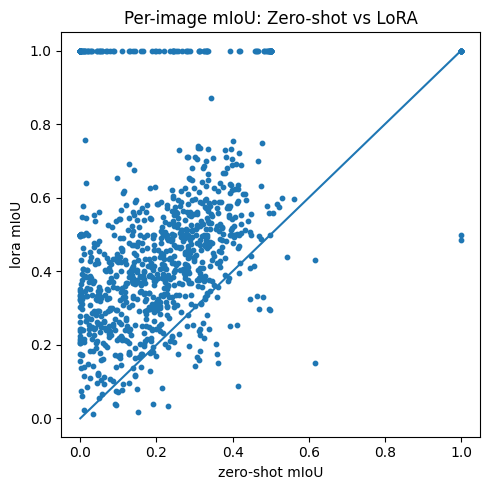

In [14]:
plt.figure(figsize=(5, 5))
plt.scatter(mzs, ml, s=10)
mn = float(np.nanmin([mzs.min(), ml.min()]))
mx = float(np.nanmax([mzs.max(), ml.max()]))
plt.plot([mn, mx], [mn, mx])  # diagonal
plt.title("Per-image mIoU: Zero-shot vs LoRA")
plt.xlabel("zero-shot mIoU")
plt.ylabel("lora mIoU")
plt.tight_layout()
plt.show()

In [15]:
rng = np.random.default_rng(0)
diff = d.dropna().to_numpy()

def bootstrap_ci_mean(x, n_boot=5000, alpha=0.05):
    m = len(x)
    means = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        samp = rng.choice(x, size=m, replace=True)
        means[i] = samp.mean()
    lo = np.quantile(means, alpha/2)
    hi = np.quantile(means, 1 - alpha/2)
    return float(x.mean()), float(lo), float(hi)

mean_diff, lo, hi = bootstrap_ci_mean(diff)
print(f"Mean ΔmIoU = {mean_diff:.4f} (95% CI: [{lo:.4f}, {hi:.4f}])")

Mean ΔmIoU = 0.2592 (95% CI: [0.2438, 0.2750])


In [16]:
per_class_cols = [c for c in miou_zs_p.columns if c.startswith("iou_")]
per_class_cols

['iou_clear', 'iou_thick_cloud', 'iou_thin_cloud', 'iou_cloud_shadow']

In [17]:
rows = []
for col in per_class_cols:
    a = pd.to_numeric(miou_zs_p[col], errors="coerce")
    b = pd.to_numeric(miou_lora_p[col], errors="coerce")
    dd = b - a
    rows.append({
        "metric": col,
        "zs_mean": float(a.mean()),
        "lora_mean": float(b.mean()),
        "delta_mean": float(dd.mean()),
        "delta_median": float(dd.median()),
        "improved_%": float((dd > 0).mean() * 100),
    })

pd.DataFrame(rows).sort_values("delta_mean", ascending=False)

,metric,zs_mean,lora_mean,delta_mean,delta_median,improved_%
1,iou_thick_cloud,0.242518,0.578559,0.356651,0.348111,69.641026
0,iou_clear,0.409369,0.638811,0.229442,0.108427,87.384615
3,iou_cloud_shadow,0.103516,0.247720,0.142030,0.115306,55.179487
2,iou_thin_cloud,0.050480,0.047151,-0.034847,0.000000,9.435897


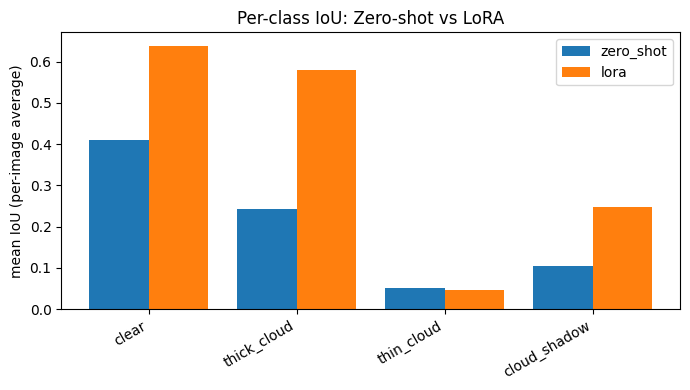

In [18]:
labels = [c.replace("iou_", "") for c in per_class_cols]
zs_means = [pd.to_numeric(miou_zs_p[c], errors="coerce").mean() for c in per_class_cols]
l_means  = [pd.to_numeric(miou_lora_p[c], errors="coerce").mean() for c in per_class_cols]

x = np.arange(len(labels))
plt.figure(figsize=(7, 4))
plt.bar(x - 0.2, zs_means, width=0.4, label="zero_shot")
plt.bar(x + 0.2, l_means,  width=0.4, label="lora")
plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("mean IoU (per-image average)")
plt.title("Per-class IoU: Zero-shot vs LoRA")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
paired = pd.DataFrame({
    "id": common_ids,
    "miou_zs": mzs.to_numpy(),
    "miou_lora": ml.to_numpy(),
})
paired["delta"] = paired["miou_lora"] - paired["miou_zs"]

print("Top improved:")
paired.sort_values("delta", ascending=False).head(10)

Top improved:


,id,miou_zs,miou_lora,delta
485,ROI_1144__20180119T092309_20180119T092446_T34RCU,0.0,1.0,1.0
648,ROI_1423__20190918T182021_20190918T182459_T12STF,0.0,1.0,1.0
367,ROI_0986__20190826T162901_20190826T163500_T17UMU,0.0,1.0,1.0
38,ROI_0069__20200510T151659_20200510T152614_T18LTM,0.0,1.0,1.0
376,ROI_0995__20190911T082601_20190911T083052_T38VLQ,0.0,1.0,1.0
264,ROI_0724__20191217T105349_20191217T105345_T31UDQ,0.0,1.0,1.0
300,ROI_0870__20190617T142049_20190617T143032_T18FXL,0.0,1.0,1.0
349,ROI_0936__20200606T080609_20200606T083047_T35LPK,0.0,1.0,1.0
952,ROI_9277__20190502T083609_20190502T084027_T37VFK,0.0,1.0,1.0
410,ROI_1071__20190209T085121_20190209T090412_T34NCL,0.0,1.0,1.0


In [20]:
print("Top harmed:")
paired.sort_values("delta", ascending=True).head(10)

Top harmed:


,id,miou_zs,miou_lora,delta
613,ROI_1368__20200527T012659_20200527T012656_T55VEH,1.000000,0.485762,-0.514238
138,ROI_0309__20191120T130249_20191120T130245_T24LTJ,1.000000,0.499939,-0.500061
244,ROI_0679__20200322T184031_20200322T184859_T11TNJ,0.617071,0.149317,-0.467754
508,ROI_1174__20190824T142751_20190824T142754_T20MMT,0.413019,0.086981,-0.326038
784,ROI_4348__20200120T053129_20200120T053410_T44SMF,0.362405,0.149606,-0.212800
400,ROI_10560__20180301T103019_20180301T103013_T33VVJ,0.498484,0.293635,-0.204849
120,ROI_0268__20190129T071209_20190129T071208_T38KNV,0.494802,0.296090,-0.198711
208,ROI_0535__20200307T184219_20200307T184220_T11TPN,0.230988,0.032281,-0.198707
287,ROI_0836__20190904T074619_20190904T081209_T35JNM,0.615879,0.430275,-0.185604
713,ROI_2696__20200218T152631_20200218T152633_T18NXM,0.357814,0.174204,-0.183609
